# Hierarchical risk parity: allocate across a correlation tree

This constructed four-asset example follows a correlation matrix into a dendrogram and then into portfolio weights. It validates the HRP mechanics without presenting a historical performance claim.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/allocation.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.figsize': (9, 4.8), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18})

## Construct two related asset groups

The annual covariance has two strong within-group correlations and weak cross-group dependence. Different volatilities keep correlation grouping distinct from capital allocation.

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from research.allocation import hrp, inverse_vol
names = ['Equity A', 'Equity B', 'Bond A', 'Bond B']
vol = np.array([0.18, 0.16, 0.08, 0.06])
corr = np.array([[1,.8,.1,.1],[.8,1,.1,.1],[.1,.1,1,.7],[.1,.1,.7,1]])
cov = np.outer(vol, vol)*corr
assert np.linalg.eigvalsh(cov).min() > 0
distance = np.sqrt((1-corr)/2)
condensed = squareform(distance, checks=True)
assert condensed.shape == (6,)
tree = linkage(condensed, method='single')
weights = pd.DataFrame({'HRP': hrp(cov), 'Inverse volatility': inverse_vol(cov)}, index=names)
display(pd.DataFrame(corr, index=names, columns=names))

,Equity A,Equity B,Bond A,Bond B
Equity A,1.0,0.8,0.1,0.1
Equity B,0.8,1.0,0.1,0.1
Bond A,0.1,0.1,1.0,0.7
Bond B,0.1,0.1,0.7,1.0


## Dependence is a structure, not a weight

The tree organizes similarity; the variance of each recursively divided group then affects its capital budget. A low-volatility group may receive most of the capital.

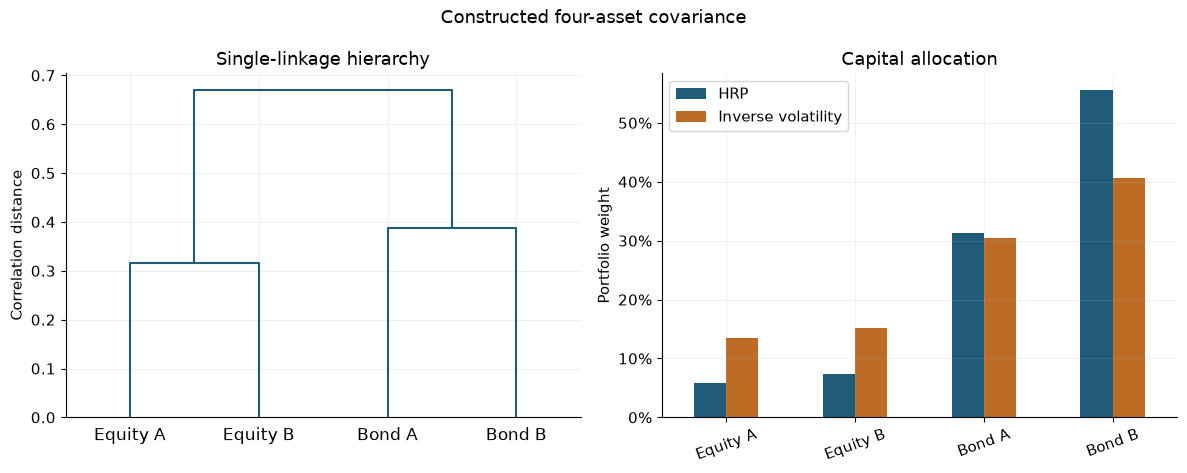

,HRP,Inverse volatility
Equity A,5.76%,13.56%
Equity B,7.29%,15.25%
Bond A,31.30%,30.51%
Bond B,55.65%,40.68%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
dendrogram(tree, labels=names, ax=axes[0], color_threshold=0, above_threshold_color='#205b78')
axes[0].set(title='Single-linkage hierarchy', ylabel='Correlation distance')
weights.plot.bar(ax=axes[1], rot=20, color=['#205b78','#bc6c25'])
axes[1].set(title='Capital allocation', ylabel='Portfolio weight')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
fig.suptitle('Constructed four-asset covariance'); fig.tight_layout(); plt.show()
display(weights.style.format('{:.2%}'))

## A hand-derived two-asset case

For variances 0.04 and 0.01, the first recursive split assigns 0.01 / (0.04 + 0.01) = 20% to the first asset, and 80% to the second. The result differs from inverse volatility.

In [4]:
two_asset_cov = np.diag([0.04, 0.01])
np.testing.assert_allclose(hrp(two_asset_cov), [0.2, 0.8], atol=1e-12)
np.testing.assert_allclose(weights.sum(), 1, atol=1e-12)
assert (weights.to_numpy() >= 0).all()
print('Condensed distances, two-asset split and portfolio budget: passed.')

Condensed distances, two-asset split and portfolio budget: passed.


## Interpretation

A readable hierarchy can help explain an allocation, but it does not supply evidence of future risk reduction. The [research note](README.md) discusses estimation and linkage choices; the [ETF report](../../docs/02-results.md) compares HRP with risk-scaled equal weight after costs.